In [59]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# Import libraries and Tools
import os
import numpy as np
import pandas as pd
import random
from PIL import Image, ImageEnhance

# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout  # Desne -> Dense olarak düzeltildi
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16  # VGG16 mimarisi transfer learning için harika seçim!

from sklearn.utils import shuffle

In [61]:
# Load Datasets
train_dir = 'Training/'
test_dir = 'Testing/'

#load and shuffle the train data
train_paths=[]
train_labels=[]

for label in os.listdir(train_dir):
    print(label)

glioma
meningioma
notumor
pituitary


In [62]:
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir,label)):
        print(image) # sırası ile bütün türleri döndürür 

Tr-gl_1.jpg
Tr-gl_10.jpg
Tr-gl_100.jpg
Tr-gl_1000.jpg
Tr-gl_1001.jpg
Tr-gl_1002.jpg
Tr-gl_1003.jpg
Tr-gl_1004.jpg
Tr-gl_1005.jpg
Tr-gl_1006.jpg
Tr-gl_1007.jpg
Tr-gl_1008.jpg
Tr-gl_1009.jpg
Tr-gl_101.jpg
Tr-gl_1010.jpg
Tr-gl_1011.jpg
Tr-gl_1012.jpg
Tr-gl_1013.jpg
Tr-gl_1014.jpg
Tr-gl_1015.jpg
Tr-gl_1016.jpg
Tr-gl_1017.jpg
Tr-gl_1018.jpg
Tr-gl_1019.jpg
Tr-gl_102.jpg
Tr-gl_1020.jpg
Tr-gl_1021.jpg
Tr-gl_1022.jpg
Tr-gl_1023.jpg
Tr-gl_1024.jpg
Tr-gl_1025.jpg
Tr-gl_1026.jpg
Tr-gl_1027.jpg
Tr-gl_1028.jpg
Tr-gl_1029.jpg
Tr-gl_103.jpg
Tr-gl_1030.jpg
Tr-gl_1031.jpg
Tr-gl_1032.jpg
Tr-gl_1033.jpg
Tr-gl_1034.jpg
Tr-gl_1035.jpg
Tr-gl_1036.jpg
Tr-gl_1037.jpg
Tr-gl_1038.jpg
Tr-gl_1039.jpg
Tr-gl_104.jpg
Tr-gl_1040.jpg
Tr-gl_1041.jpg
Tr-gl_1042.jpg
Tr-gl_1043.jpg
Tr-gl_1044.jpg
Tr-gl_1045.jpg
Tr-gl_1046.jpg
Tr-gl_1047.jpg
Tr-gl_1048.jpg
Tr-gl_1049.jpg
Tr-gl_105.jpg
Tr-gl_1050.jpg
Tr-gl_1051.jpg
Tr-gl_1052.jpg
Tr-gl_1053.jpg
Tr-gl_1054.jpg
Tr-gl_1055.jpg
Tr-gl_1056.jpg
Tr-gl_1057.jpg
Tr-gl_1058.jpg
Tr-gl_

In [63]:
# karıştırmak lzm
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir,label)):
        train_paths.append(os.path.join(train_dir,label,image))
        train_labels.append(label)
        
train_paths, train_labels=shuffle(train_paths,train_labels)
train_paths


['Training/meningioma\\Tr-me_790.jpg',
 'Training/notumor\\Tr-no_488.jpg',
 'Training/pituitary\\Tr-pi_906.jpg',
 'Training/glioma\\Tr-gl_1034.jpg',
 'Training/meningioma\\Tr-aug-me_96.jpg',
 'Training/pituitary\\Tr-pi_701.jpg',
 'Training/notumor\\Tr-no_1272.jpg',
 'Training/notumor\\Tr-no_468.jpg',
 'Training/meningioma\\Tr-me_36.jpg',
 'Training/meningioma\\Tr-me_814.jpg',
 'Training/glioma\\Tr-gl_142.jpg',
 'Training/glioma\\Tr-gl_1344.jpg',
 'Training/pituitary\\Tr-pi_107.jpg',
 'Training/notumor\\Tr-no_1116.jpg',
 'Training/meningioma\\Tr-me_166.jpg',
 'Training/notumor\\Tr-no_101.jpg',
 'Training/notumor\\Tr-no_875.jpg',
 'Training/glioma\\Tr-gl_747.jpg',
 'Training/meningioma\\Tr-me_256.jpg',
 'Training/meningioma\\Tr-me_322.jpg',
 'Training/meningioma\\Tr-me_463.jpg',
 'Training/glioma\\Tr-gl_638.jpg',
 'Training/notumor\\Tr-no_507.jpg',
 'Training/glioma\\Tr-gl_1175.jpg',
 'Training/glioma\\Tr-gl_399.jpg',
 'Training/notumor\\Tr-no_567.jpg',
 'Training/pituitary\\Tr-pi_1032.j

In [64]:
# Load and shuffle the test data
test_paths=[]
test_labels=[]

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir,label)):
        test_paths.append(os.path.join(test_dir,label,image))
        test_labels.append(label)

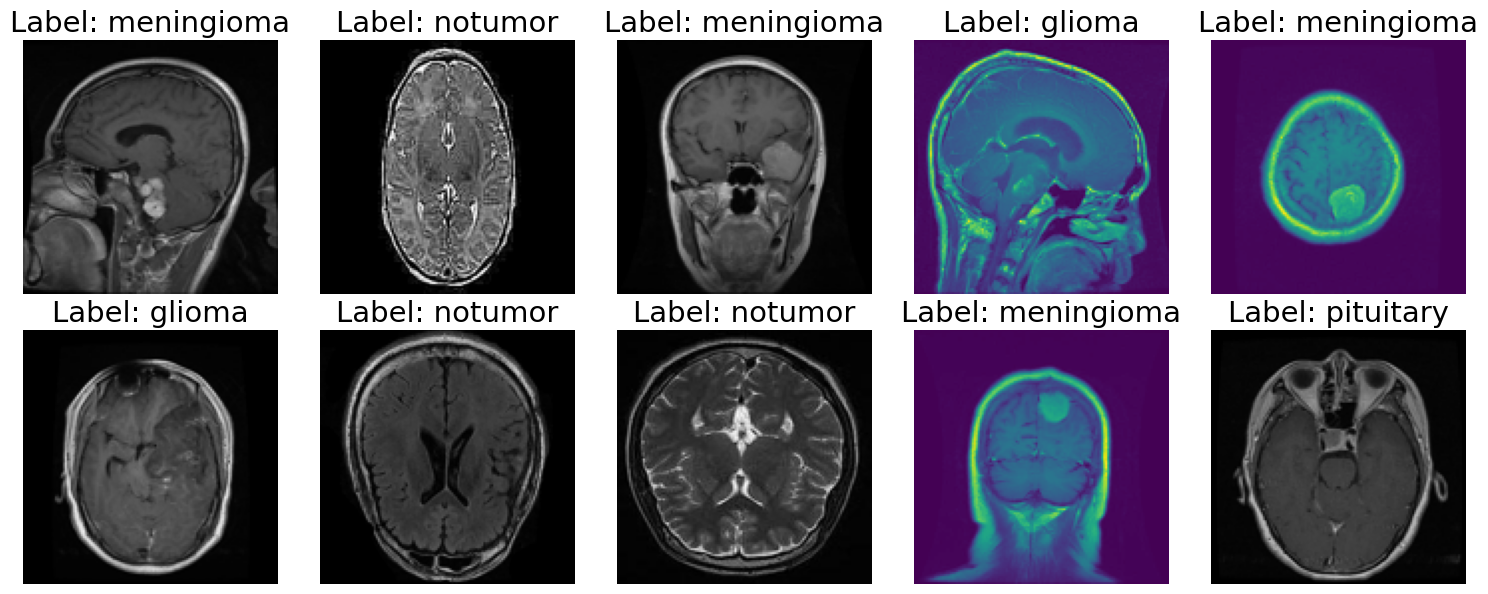

In [65]:
# Data Visualization
import random
import matplotlib.pyplot as plt

#select random indcies for 10 images
random_indices=random.sample(range(len(train_paths)),10)
random_indices


#Create a figure to display images in 2 rows
fig,axes=plt.subplots(2,5,figsize=(15,6))
axes=axes.flatten()

#Loop through the random indices and display images
for i, inx in enumerate(random_indices):
    img_path=train_paths[inx]
    img=Image.open(img_path)
    img=img.resize((128,128))
    #Display images
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {train_labels[inx]}",fontsize=21)
    axes[i].axis('off')
    
    
    
plt.tight_layout()
plt.show()

In [66]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [67]:
## MODEL WE ARE USİNG VGG16 FOR TRANSFER LEARNING

In [68]:
len(os.listdir(train_dir))

4

In [69]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - loss: 0.4773 - sparse_categorical_accuracy: 0.8146
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - loss: 0.2507 - sparse_categorical_accuracy: 0.9023
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - loss: 0.1712 - sparse_categorical_accuracy: 0.9312
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - loss: 0.1273 - sparse_categorical_accuracy: 0.9514
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - loss: 0.0958 - sparse_categorical_accuracy: 0.9648


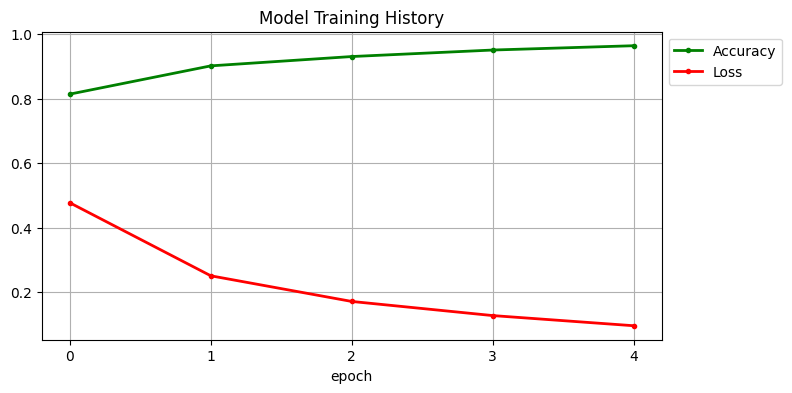

In [71]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2)
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'],loc='upper left',bbox_to_anchor=(1,1))
plt.show()

In [75]:
import os

test_paths = []
test_labels = []

# Sadece gerçek dosyaları (resimleri) listeye ekleyen güvenli döngü
for label in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label)
    if os.path.isdir(label_path): 
        for image_name in os.listdir(label_path):
            image_path = os.path.join(label_path, image_name)
            
            # CRITICAL CHECK: Eğer bu yol bir klasör değil de GERÇEK BİR DOSYA ise ekle
            if os.path.isfile(image_path):
                test_paths.append(image_path)
                test_labels.append(label)

print("Filtrelenmiş Temiz Test Resmi Sayısı:", len(test_paths))
print("İlk test resmi yolu:", test_paths[0] if test_paths else "Liste boş!")

# ŞİMDİ TAHMİN ADIMINI DOĞRUDAN BURADA TETİKLEYELİM (Risk almayalım)
if test_paths:
    test_images = open_images(test_paths)
    # Eğer yukarıdaki fonksiyon adın encode_label ise burayı ona göre eşitle kanka
    test_labels_encoded = encode_label(test_labels) 
    test_predictions = model.predict(test_images)
    print("Tahminler başarıyla alındı! Model coşturuyor.")

Filtrelenmiş Temiz Test Resmi Sayısı: 1600
İlk test resmi yolu: Testing/glioma\Te-gl_1.jpg
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step
Tahminler başarıyla alındı! Model coşturuyor.


In [77]:
#Model Classification report
from sklearn.metrics import classification_report, confusion_matrix, roc_curve,auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images=open_images(test_paths)
test_labels_encoded=encode_label(test_labels)
test_predictions=model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions,axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       400
           1       0.79      0.98      0.87       400
           2       0.96      0.98      0.97       400
           3       0.99      0.97      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.91      1600
weighted avg       0.93      0.92      0.91      1600



Confusion Matrix:
[[292  89  16   3]
 [  5 391   2   2]
 [  1   5 394   0]
 [  0  13   0 387]]


Text(70.72222222222221, 0.5, 'True')

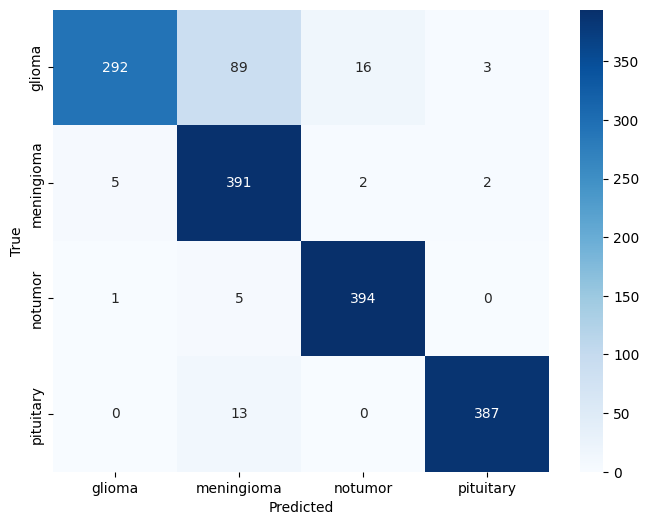

In [81]:
#Model confusion plot
conf_matris=confusion_matrix(test_labels_encoded, np.argmax(test_predictions,axis=1))
print('Confusion Matrix:')
print(conf_matris)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matris, annot=True,fmt='d',cmap='Blues',xticklabels=os.listdir(train_dir),yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')


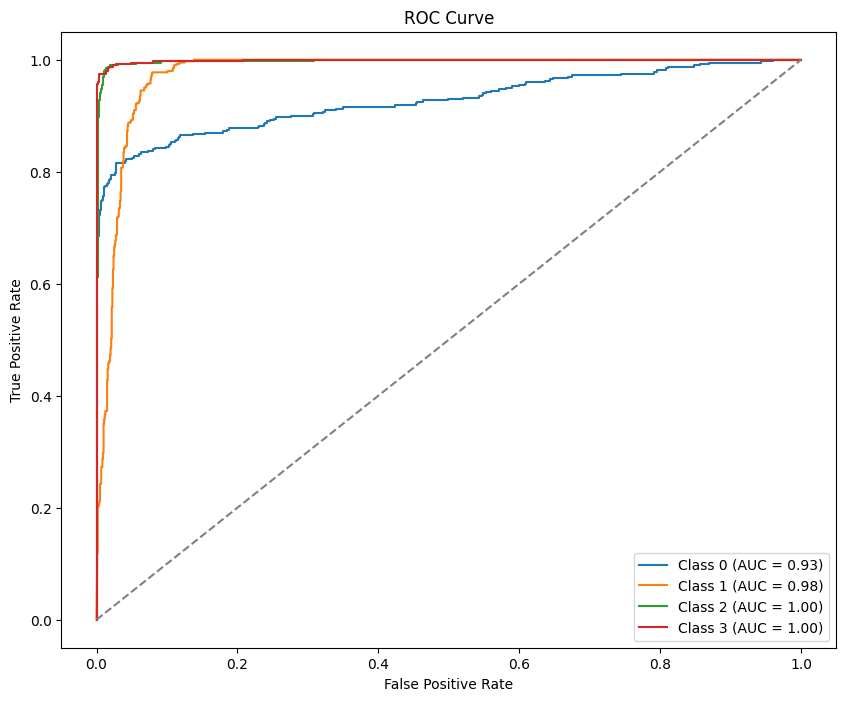

In [82]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [83]:
# Save and load model
model.save('model.h5')

In [84]:
from tensorflow.keras.models import load_model
#Load the trained model
model=load_model('model.h5')

In [97]:
# MRI Tumor Detection System
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

def detect_and_display(image_path, model):
    try:
        # HATA DÜZELTİLDİ: 'img_path' yerine artık 'image_path' kullanılıyor!
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        # prediction
        predictions = model.predict(img_array) 
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions, axis=1)[0]
        
        # determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor Detected"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"
            
        # HATA DÜZELTİLDİ: Görselleştirme kısmındaki 'img_path' de 'image_path' yapıldı
        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (confidence:) {confidence_score*100:.2f}%")
        plt.show()
        
    except Exception as e:
        print("Error processing the image:", str(e))

In [109]:
import os
print("Şu an buradayım kanka:", os.getcwd())
print("İçindeki dosyalar:", os.listdir())

Şu an buradayım kanka: c:\Users\computeer\Desktop\pytorch\Projects
İçindeki dosyalar: ['comp_vis.ipynb', 'deneme_resimleri', 'model.h5', 'Testing', 'Training']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


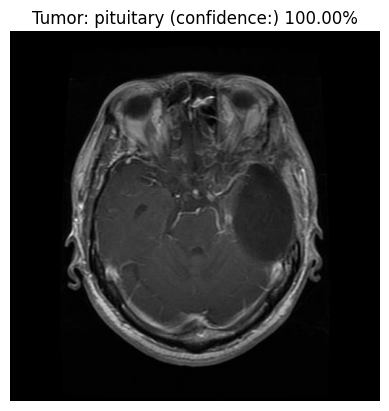

In [110]:
image_path = 'deneme_resimleri/Te-gl_0015.jpg'
detect_and_display(image_path, model)

--- Meningioma Tahmini ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


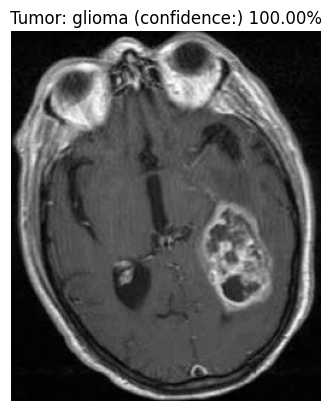


--- No Tumor Tahmini ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


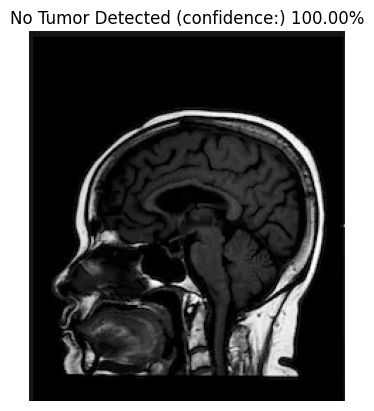


--- Pituitary Tahmini ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


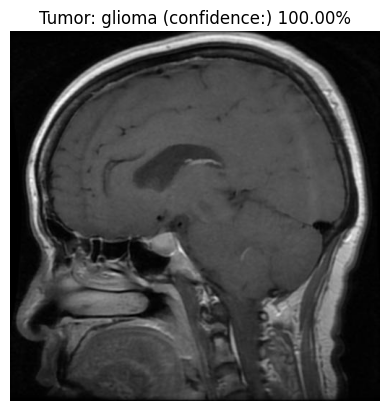

In [111]:
# Diğer tüm deneme resimlerinin yolları
meningioma_path = 'deneme_resimleri/Te-meTr_0001.jpg'
notumor_path    = 'deneme_resimleri/Te-noTr_0004.jpg'
pituitary_path  = 'deneme_resimleri/Te-piTr_0003.jpg'

print("--- Meningioma Tahmini ---")
detect_and_display(meningioma_path, model)

print("\n--- No Tumor Tahmini ---")
detect_and_display(notumor_path, model)

print("\n--- Pituitary Tahmini ---")
detect_and_display(pituitary_path, model)